In [1]:
# library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
# from keras.models import Sequential
# from keras.layers import Dense, ConV1D, Flatten, MaxPooling2D, Input, Bidirectional, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.keras
sns.set(style="darkgrid")

In [2]:
# data aquisition
df = pd.read_csv("/Users/faizshaikh/Documents/machine_learning/classData.xls", sep=",", index_col=False)
# df.drop(columns=["Unnamed: 7", "Unnamed: 8"], inplace=True)
print(df.head())

   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  


In [3]:
print(df.describe())

                 G            C            B            A           Ia  \
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000   
mean      0.432006     0.411271     0.555527     0.571429    13.721194   
std       0.495387     0.492095     0.496939     0.494903   464.741671   
min       0.000000     0.000000     0.000000     0.000000  -883.542316   
25%       0.000000     0.000000     0.000000     0.000000  -119.802518   
50%       0.000000     0.000000     1.000000     1.000000     2.042805   
75%       1.000000     1.000000     1.000000     1.000000   227.246377   
max       1.000000     1.000000     1.000000     1.000000   885.738571   

                Ib           Ic           Va           Vb           Vc  
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000  
mean    -44.845268    34.392394    -0.007667     0.001152     0.006515  
std     439.269195   371.107412     0.289150     0.313437     0.307897  
min    -900.526951  -883.357762    -0.620

In [4]:
print(df.dtypes)

G       int64
C       int64
B       int64
A       int64
Ia    float64
Ib    float64
Ic    float64
Va    float64
Vb    float64
Vc    float64
dtype: object


In [5]:
df.isna().sum()

G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64

In [6]:
# temporary sum variable
phase_sum = df['A'] + df['B'] + df['C']
g = df['G']

# conditions and corresponding labels
conditions = [
    (g == 0) & (phase_sum == 3),
    (g == 0) & (phase_sum == 2),
    (g == 0) & (phase_sum < 2),
    (g == 1) & (phase_sum == 3),
    (g == 1) & (phase_sum == 2),
    (g == 1) & (phase_sum == 1)
]

outputs = ["LLL", "LL", "No Fault", "LLLG", "LLG", "LG"]

df['fault_type'] = np.select(conditions, outputs, default="Unknown")
df.drop(columns=['A', 'B', 'C', 'G'], inplace=True)

print(df.head())

           Ia          Ib          Ic        Va        Vb        Vc fault_type
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815         LG
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099         LG
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428         LG
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570         LG
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983         LG


In [7]:
print(df.dtypes)

Ia            float64
Ib            float64
Ic            float64
Va            float64
Vb            float64
Vc            float64
fault_type     object
dtype: object


In [8]:
df["fault_type"].value_counts()

fault_type
No Fault    2365
LLG         1134
LLLG        1133
LG          1129
LLL         1096
LL          1004
Name: count, dtype: int64

<Axes: xlabel='fault_type', ylabel='count'>

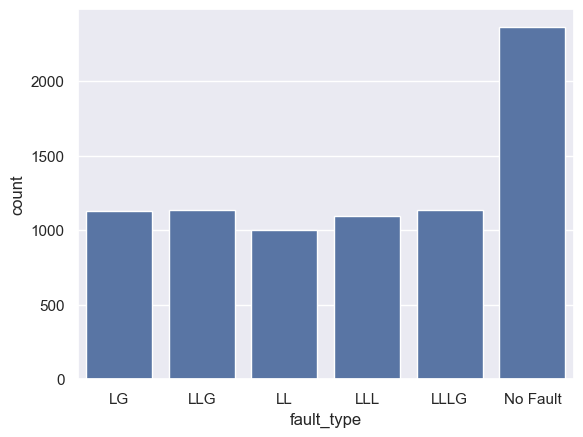

In [9]:
sns.countplot(x=df["fault_type"])

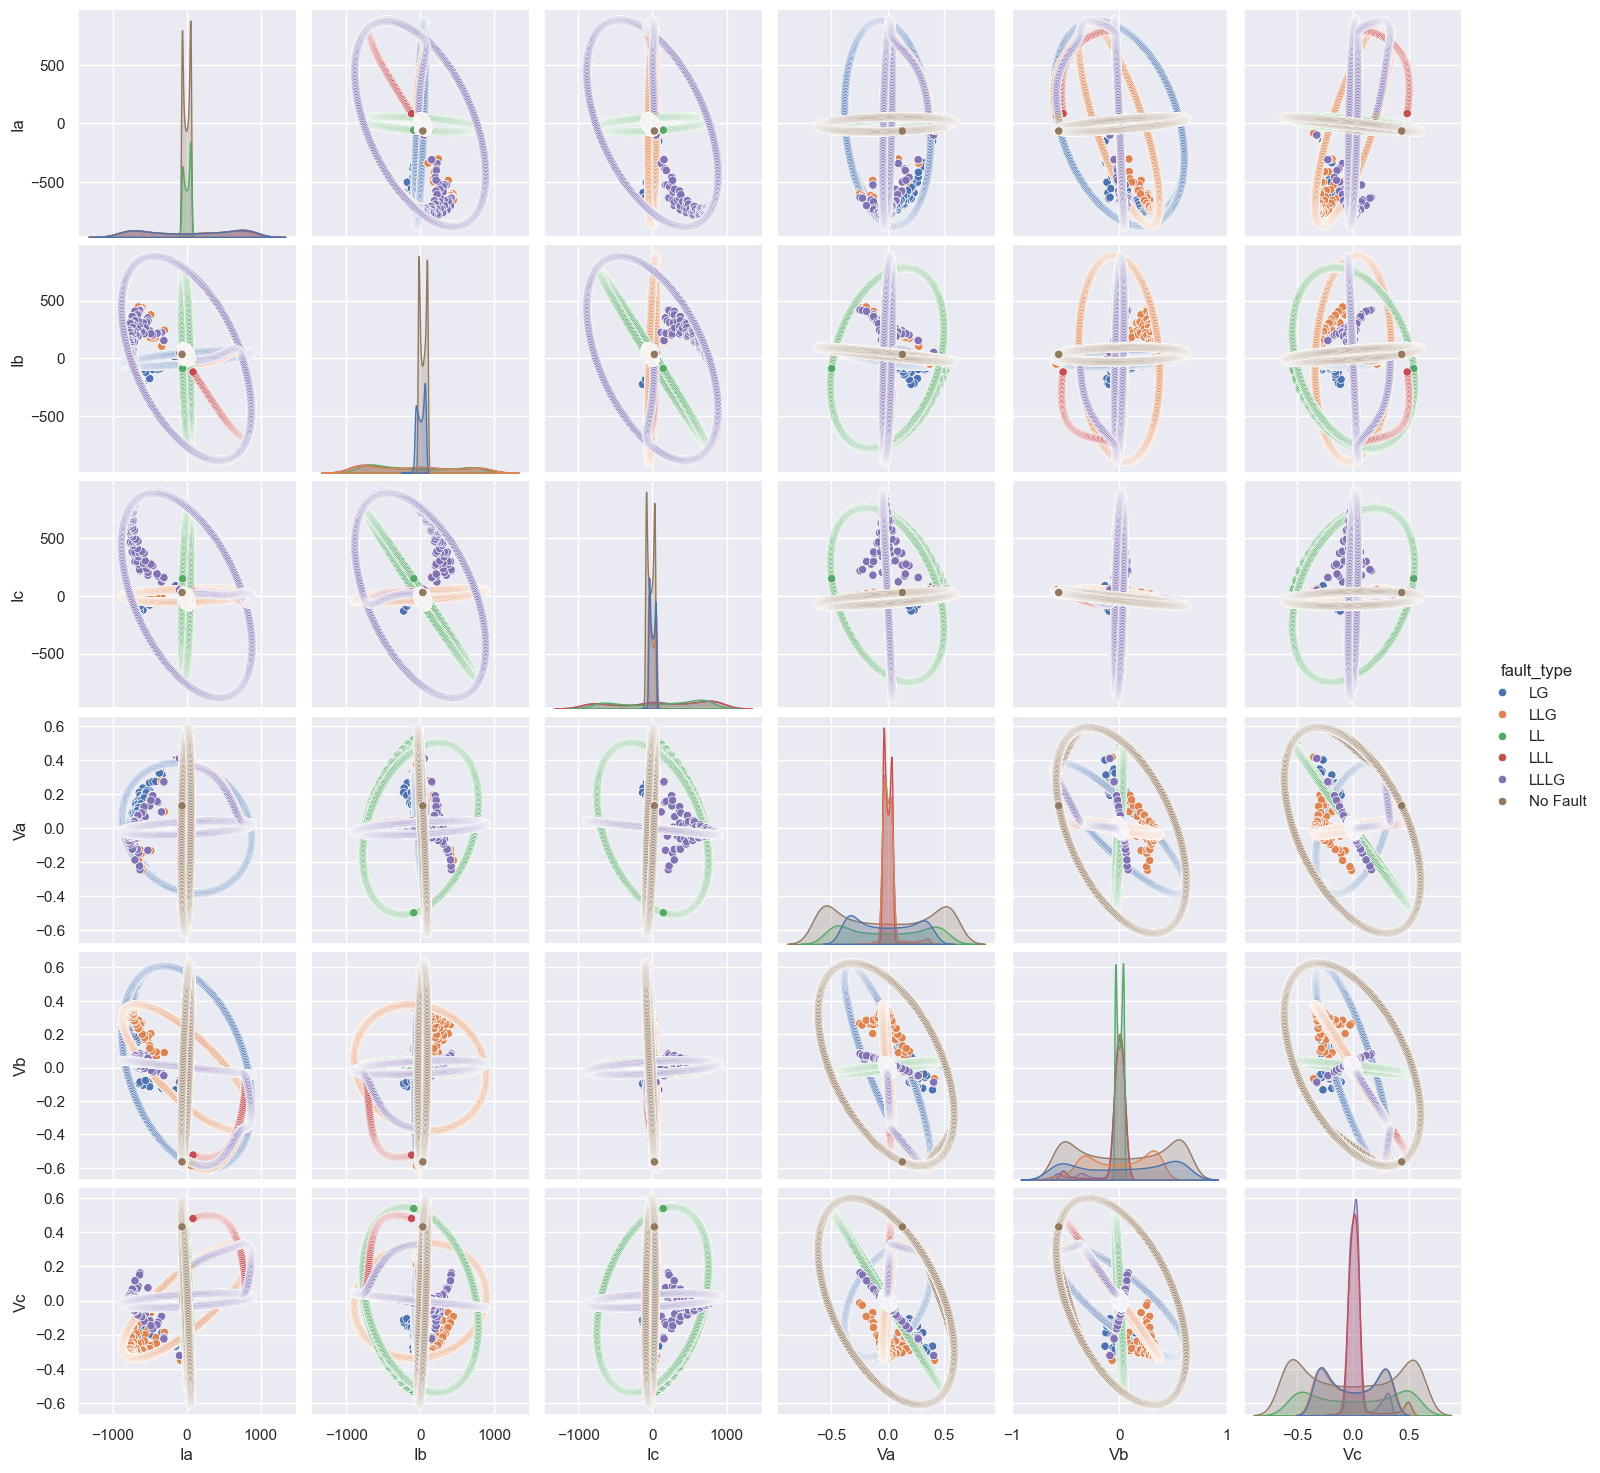

In [10]:
sns.pairplot(df, hue="fault_type")

In [11]:
# data preprocessing
le = LabelEncoder()
df["fault_type"] = le.fit_transform(df["fault_type"])
print(df.head())

           Ia          Ib          Ic        Va        Vb        Vc  \
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815   
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099   
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428   
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570   
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983   

   fault_type  
0           0  
1           0  
2           0  
3           0  
4           0  


In [12]:
print(df.dtypes)

Ia            float64
Ib            float64
Ic            float64
Va            float64
Vb            float64
Vc            float64
fault_type      int64
dtype: object


In [13]:
df["fault_type"].value_counts()

fault_type
5    2365
2    1134
4    1133
0    1129
3    1096
1    1004
Name: count, dtype: int64

Text(0.5, 1.0, 'Spearman')

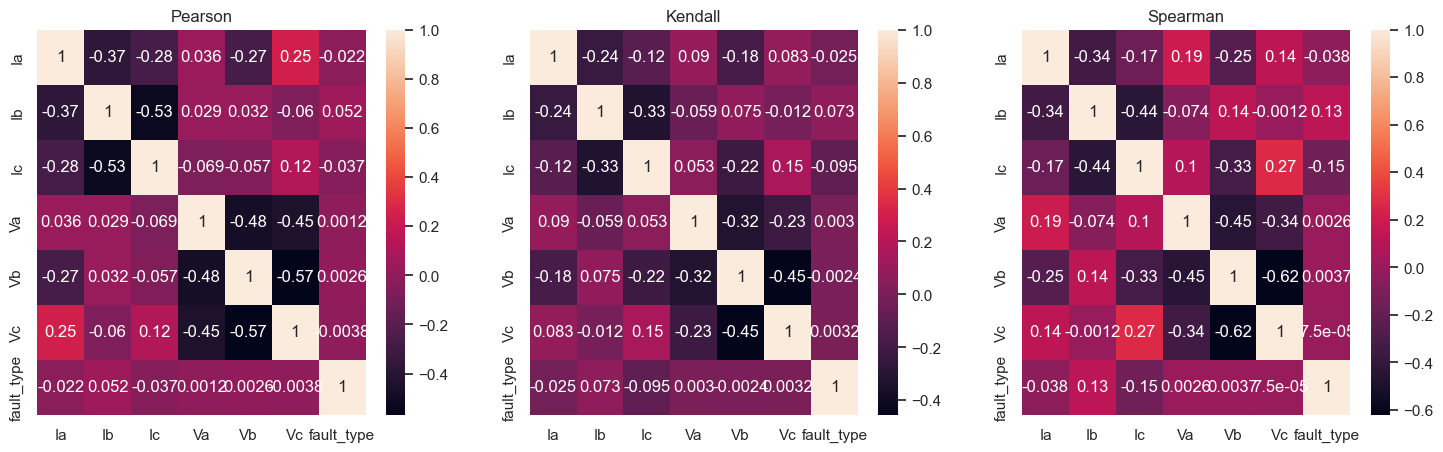

In [14]:
# correlation plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: Pearson (Linear correlation)
sns.heatmap(df.corr(method="pearson"), annot=True, ax=axes[0])
axes[0].set_title("Pearson")

# plot 2: Kendall (Ordinal association)
sns.heatmap(df.corr(method="kendall"), annot=True, ax=axes[1])
axes[1].set_title("Kendall")

# plot 3: Spearman (Rank correlation)
sns.heatmap(df.corr(method="spearman"), annot=True, ax=axes[2])
axes[2].set_title("Spearman")

In [15]:
# Splitting the dataset
total_rows = len(df)
step = total_rows // 500

X_train, X_test, y_train, y_test = train_test_split(df, df["fault_type"], test_size=0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)
y_train_cat = tf.keras.utils.to_categorical(y_train)
y_test_cat = tf.keras.utils.to_categorical(y_test)
y_val_cat = tf.keras.utils.to_categorical(y_val)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)
print(y_train_cat.shape, y_val_cat.shape, y_test_cat.shape)

(5895, 7) (983, 7) (983, 7)
(5895,) (983,) (983,)
(5895, 6) (983, 6) (983, 6)


In [16]:
# developing models
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=((7,)), name="Input_Layer"))
model.add(tf.keras.layers.Reshape((1, 7)))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(24), name="Bidirectional_LSTM_1"))
model.add(tf.keras.layers.Dropout(0.2, name="Dropout_1"))
model.add(tf.keras.layers.Dense(24, activation="relu", name="Dense_1"))
model.add(tf.keras.layers.Dense(6, activation="softmax", name="Output_Layer"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
print(model.summary())

2026-01-29 12:55:45.528905: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-01-29 12:55:45.529004: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-01-29 12:55:45.529019: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-01-29 12:55:45.529040: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-29 12:55:45.529056: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bidirectional_LSTM_1            │ (None, 48)             │         6,144 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 6)              │           150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,470 (29.18 KB)

 Trainable params: 7,470 (29.18 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
history = model.fit(X_train, y_train_cat, epochs=50, verbose=1, validation_data=(X_val, y_val_cat))

Epoch 1/50


2026-01-29 12:55:46.542890: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.4645 - loss: 1.4156 - val_accuracy: 0.6063 - val_loss: 1.1547
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6667 - loss: 0.9845 - val_accuracy: 0.7223 - val_loss: 0.8251
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.7440 - loss: 0.7142 - val_accuracy: 0.7762 - val_loss: 0.5980
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7771 - loss: 0.5509 - val_accuracy: 0.7731 - val_loss: 0.4982
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7813 - loss: 0.5033 - val_accuracy: 0.7579 - val_loss: 0.4964
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7874 - loss: 0.4844 - val_accuracy: 0.7752 - val_loss: 0.4941
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.7856 - loss: 0.4810 - val_accuracy: 0.8006 - val_loss: 0.4429
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.7988 - loss: 0.4459 - val_accurac

In [18]:
# classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(y_pred.shape)
print(classification_report(y_test_cat, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
(983, 6)
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       138
           1       0.84      0.98      0.91       127
           2       0.98      0.95      0.96       130
           3       0.51      0.25      0.33       151
           4       0.46      0.49      0.47       146
           5       1.00      1.00      1.00       291

   micro avg       0.84      0.80      0.82       983
   macro avg       0.79      0.78      0.78       983
weighted avg       0.82      0.80      0.80       983
 samples avg       0.80      0.80      0.80       983



/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


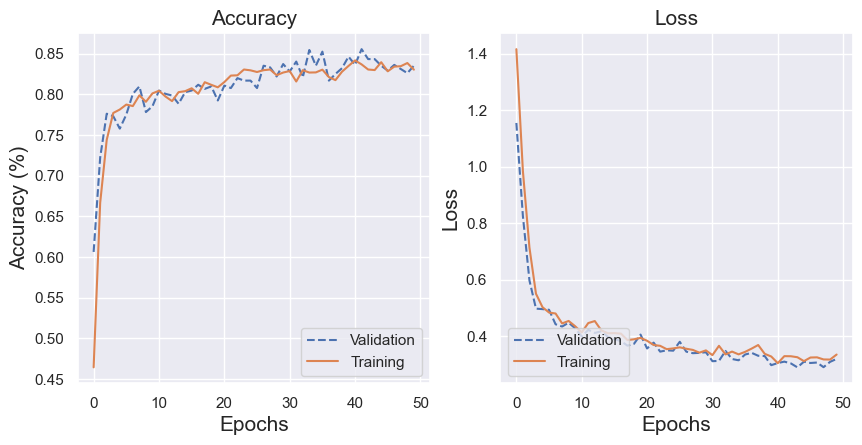

In [19]:
fig = plt.figure(figsize=(10, 10))

# summarize history for accuracy
plt.subplot(2, 2, 1)

plt.title("Accuracy", fontsize=15)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.plot(history.history["val_accuracy"],
label='Validation Accuracy', linestyle='dashed')
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.legend(["Validation", "Training"], loc="lower right")

plt.subplot(2, 2, 2)
plt.title("Loss", fontsize=15)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.plot(history.history["val_loss"], label='Validation loss', linestyle='dashed')
plt.plot(history.history["loss"], label='Training loss')
plt.legend(["Validation", "Training"], loc="lower left")



<Axes: >

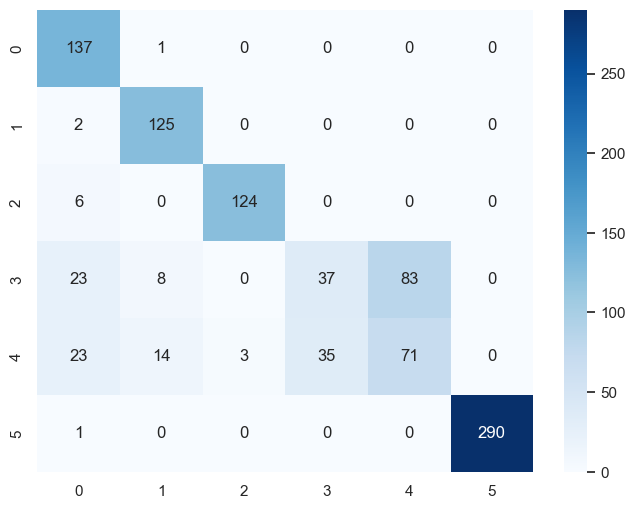

In [22]:
# confusion matrix
cf_matrix = confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(y_pred, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt="d", cmap="Blues")